# Análise Qualitativa de Erros (TCC TLR)
Neste notebook, vamos investigar as falhas cometidas pelos modelos na avaliação final (Falsos Positivos e Falsos Negativos).
Temos os seguintes objetivos de pesquisa:
1. **Falsos Positivos (Alucinações):** Onde modelos de alta precisão (como o Claude 3.5 Sonnet ou DeepSeek) falharam?
2. **Falsos Negativos (Omissões):** Quais elos o GPT-4o-mini (nosso campeão) deixou passar no Few-Shot?


In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../src')
from data_loader import get_stratified_evaluation_dataset

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carrega a base de instâncias oficiais (req_text, test_text, ground_truth)
df_itrust = get_stratified_evaluation_dataset()
df_itrust['pair_id'] = df_itrust.index + 1

# Carrega a base de predições que o Antigravity extraiu dos logs
df_preds = pd.read_csv('../data/processed/predictions_raw.csv')

# Junta as duas bases (Merge)
df = df_preds.merge(df_itrust, on=['pair_id', 'ground_truth'], how='left')

print(f"Total de predições carregadas: {len(df)}")
df.head()


Carregando dataset processado de C:\Users\Lucas Luis\Documents\tcc-tlr-llm\data\processed\itrust_processed.csv...


Base oficial de avaliação criada com 858 pares:
  - Pares positivos (1): 286
  - Pares negativos (0): 572 (proporção 1:2)
Total de predições carregadas: 12870


,model,strategy,pair_id,ground_truth,prediction,req_id,req_text,test_id,test_text
0,anthropic/claude-3.5-sonnet,Zero-Shot,1,0,0,UC30S1.txt,A patient or personal representative for a pat...,RemoteMonitoringDataBeanValidator.java,package edu.ncsu.csc.itrust.validate;\n\nimpor...
1,anthropic/claude-3.5-sonnet,Zero-Shot,2,0,0,UC30S3.txt,A patient or patient representative wishes to ...,PatientLoader.java,package edu.ncsu.csc.itrust.beans.loaders;\n\n...
2,anthropic/claude-3.5-sonnet,Zero-Shot,3,1,0,UC27S2.txt,The status of a laboratory procedure has been ...,EmailUtil.java,package edu.ncsu.csc.itrust;\n\nimport edu.ncs...
3,anthropic/claude-3.5-sonnet,Zero-Shot,4,1,1,UC36S1.txt,A public health agent is presented with a list...,EmailUtil.java,package edu.ncsu.csc.itrust;\n\nimport edu.ncs...
4,anthropic/claude-3.5-sonnet,Zero-Shot,5,0,0,UC1S1.txt,The HCP enters a patient as a new user of iTru...,BeanLoader.java,package edu.ncsu.csc.itrust.beans.loaders;\n\n...


## 1. Investigação de Falsos Positivos (FP) - "Alucinações"
Modelos como **Claude 3.5 Sonnet** e **DeepSeek** apresentaram Precisão altíssima (muitas vezes acima de 95%). Isso significa que eles raramente "alucinam" um elo. 
Vamos isolar as raras vezes em que eles preveram `1` quando a realidade era `0`.


In [2]:
# Filtra Falsos Positivos (Previu 1, mas Real é 0)
df_fp = df[(df['prediction'] == 1) & (df['ground_truth'] == 0)]

# Vamos olhar os Falsos Positivos apenas do Claude e DeepSeek
modelos_alta_precisao = ['anthropic/claude-3.5-sonnet', 'deepseek/deepseek-chat']
df_fp_high_prec = df_fp[df_fp['model'].isin(modelos_alta_precisao)]

print(f"Total de Falsos Positivos nos modelos de alta precisão: {len(df_fp_high_prec)}")
display(df_fp_high_prec.groupby(['model', 'strategy']).size().reset_index(name='FP Count'))


Total de Falsos Positivos nos modelos de alta precisão: 13


,model,strategy,FP Count
0,anthropic/claude-3.5-sonnet,Chain-of-Thought (CoT),2
1,anthropic/claude-3.5-sonnet,Few-Shot,4
2,anthropic/claude-3.5-sonnet,Zero-Shot,4
3,deepseek/deepseek-chat,Chain-of-Thought (CoT),2
4,deepseek/deepseek-chat,Few-Shot,1


In [3]:
# Imprime um exemplo de Falso Positivo para análise semântica
if not df_fp_high_prec.empty:
    amostra_fp = df_fp_high_prec.iloc[0]
    print(f"MODELO: {amostra_fp['model']} | ESTRATÉGIA: {amostra_fp['strategy']}")
    print("="*80)
    print(f"REQUISITO:\n{amostra_fp['req_text']}")
    print("-" * 80)
    print(f"CASO DE TESTE:\n{amostra_fp['test_text'][:1000]}... [truncado]")


MODELO: anthropic/claude-3.5-sonnet | ESTRATÉGIA: Zero-Shot
REQUISITO:
The administrator will store (1) hospital Id number for the hospital [E1]; and (2) up to 30 alphanumeric characters giving the name of the hospital
--------------------------------------------------------------------------------
CASO DE TESTE:
package edu.ncsu.csc.itrust.validate;

import java.text.ParseException;
import java.text.SimpleDateFormat;
import java.util.Date;
import edu.ncsu.csc.itrust.action.EditOfficeVisitAction;
import edu.ncsu.csc.itrust.beans.forms.EditOfficeVisitForm;
import edu.ncsu.csc.itrust.exception.ErrorList;
import edu.ncsu.csc.itrust.exception.FormValidationException;

/**
 * Used to validate updating an office visit, by {@link EditOfficeVisitAction}
 * 
 * @author Andy
 * 
 */
public class EditOfficeVisitValidator extends BeanValidator<EditOfficeVisitForm> {
	private boolean validatePrescription = false;

	/**
	 * The default constructor.
	 */
	public EditOfficeVisitValidator() {
	}

	publ

## 2. Investigação de Falsos Negativos (FN) - "Omissões"
O **GPT-4o-mini** foi o campeão de Revocação, principalmente usando **Few-Shot**.
Vamos isolar as instâncias que ele *perdeu* (Previu `0` quando a realidade era `1`) para entender as limitações atuais dessa técnica.


In [4]:
# Filtra Falsos Negativos (Previu 0, mas Real é 1)
df_fn = df[(df['prediction'] == 0) & (df['ground_truth'] == 1)]

# Isola o campeão: GPT-4o-mini (Few-Shot)
df_fn_gpt = df_fn[(df_fn['model'] == 'openai/gpt-4o-mini') & (df_fn['strategy'] == 'Few-Shot')]

print(f"Total de Falsos Negativos do GPT-4o-mini (Few-Shot): {len(df_fn_gpt)} de 286 elos reais possíveis.")


Total de Falsos Negativos do GPT-4o-mini (Few-Shot): 130 de 286 elos reais possíveis.


In [5]:
# Imprime um exemplo de Falso Negativo para análise
if not df_fn_gpt.empty:
    amostra_fn = df_fn_gpt.iloc[0]
    print(f"MODELO: {amostra_fn['model']} | ESTRATÉGIA: {amostra_fn['strategy']}")
    print("="*80)
    print(f"REQUISITO:\n{amostra_fn['req_text']}")
    print("-" * 80)
    print(f"CASO DE TESTE:\n{amostra_fn['test_text'][:1000]}... [truncado]")


MODELO: openai/gpt-4o-mini | ESTRATÉGIA: Few-Shot
REQUISITO:
The status of a laboratory procedure has been updated (UC26, S3). The patient is notified with the following information: the LOINC number and the updated status.
--------------------------------------------------------------------------------
CASO DE TESTE:
package edu.ncsu.csc.itrust;

import edu.ncsu.csc.itrust.beans.Email;
import edu.ncsu.csc.itrust.dao.DAOFactory;
import edu.ncsu.csc.itrust.exception.DBException;

/**
 * Sends email to users. Since we don't want to train spammers in 326, this just inserts into a database. If
 * we put this into an actual system, we would replace this class with stuff from javax.mail
 * 
 * @author Andy
 * 
 */
public class EmailUtil {
	private DAOFactory factory;

	public EmailUtil(DAOFactory factory) {
		this.factory = factory;
	}

	// DO NOT SEND REAL EMAILS!!!!!
	// Sending emails - even to a throwaway account, is a waste of bandwidth and looks very suspicious.
	// If you want to know

## 3. Visualização: Tipos de Erros por Estratégia
Qual estratégia induz mais alucinações (FP) e qual induz mais omissões (FN)?


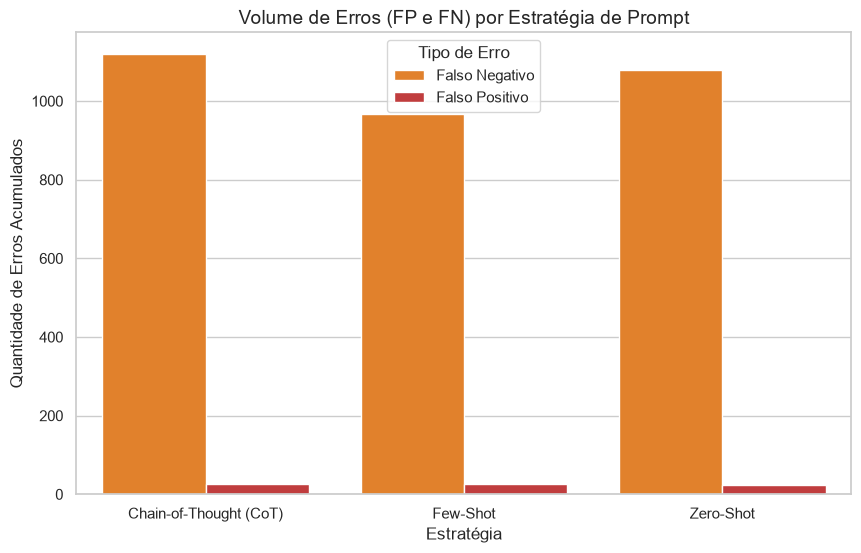

In [6]:
df['error_type'] = 'Correto'
df.loc[(df['prediction'] == 1) & (df['ground_truth'] == 0), 'error_type'] = 'Falso Positivo'
df.loc[(df['prediction'] == 0) & (df['ground_truth'] == 1), 'error_type'] = 'Falso Negativo'

# Agrupa por estratégia e tipo de erro
erros_por_estrategia = df[df['error_type'] != 'Correto'].groupby(['strategy', 'error_type']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(data=erros_por_estrategia, x='strategy', y='count', hue='error_type', palette=['#ff7f0e', '#d62728'])
plt.title("Volume de Erros (FP e FN) por Estratégia de Prompt", fontsize=14)
plt.ylabel("Quantidade de Erros Acumulados")
plt.xlabel("Estratégia")
plt.legend(title="Tipo de Erro")
plt.show()
